# 3-Foot Spaced Points — Standalone Geometry Demo

This notebook reproduces the **core geometry logic** of the `ThreeFootSpacedPoints.pyt` ArcGIS toolbox, using only open-source Python (`shapely` + `matplotlib`) instead of `arcpy`.

It exists so you can see and run the algorithm without needing an ArcGIS Pro license. The production tool (in the parent folder) does the same math, but reads/writes real feature classes inside ArcGIS.

Two behaviors are demonstrated:
1. **Line mode** — given two points, place points every 3 feet along the line between them, skipping any point within 2 feet of either endpoint.
2. **Circle mode** — given a center point and an edge point (which defines the radius), place points every 3 feet around the circle's circumference.

In [1]:
import math
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString

SPACING = 3.0            # feet between generated points
MIN_ENDPOINT_DISTANCE = 2.0  # feet — skip generated points this close to an endpoint

## Line mode

In [2]:
def generate_points_along_line(pt1, pt2, spacing=SPACING, min_threshold=MIN_ENDPOINT_DISTANCE):
    """Mirrors generate_points_along_line() from the .pyt, using shapely instead of arcpy."""
    line = LineString([pt1, pt2])
    total_length = line.length
    points = []
    distance_along = 0.0
    while distance_along <= total_length:
        candidate = line.interpolate(distance_along)
        if candidate.distance(Point(pt1)) >= min_threshold and candidate.distance(Point(pt2)) >= min_threshold:
            points.append(candidate)
        distance_along += spacing
    return line, points

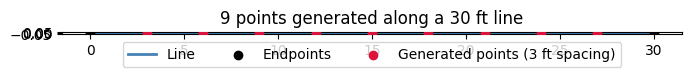

In [3]:
# Example: a 30-foot line
pt1, pt2 = (0, 0), (30, 0)
line, pts = generate_points_along_line(pt1, pt2)

fig, ax = plt.subplots(figsize=(8, 2))
x, y = line.xy
ax.plot(x, y, color="steelblue", linewidth=2, label="Line")
ax.scatter([pt1[0], pt2[0]], [pt1[1], pt2[1]], color="black", zorder=5, label="Endpoints")
ax.scatter([p.x for p in pts], [p.y for p in pts], color="crimson", zorder=5, label="Generated points (3 ft spacing)")
ax.set_aspect("equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3)
ax.set_title(f"{len(pts)} points generated along a 30 ft line")
plt.show()

## Circle mode

In [4]:
def generate_points_on_circle(center_pt, radius, spacing=SPACING):
    """Mirrors generate_points_on_circle() from the .pyt."""
    angle_step = spacing / radius
    num_points = int(2 * math.pi / angle_step)
    points = []
    for i in range(num_points):
        angle = i * angle_step
        x = center_pt[0] + radius * math.cos(angle)
        y = center_pt[1] + radius * math.sin(angle)
        points.append(Point(x, y))
    return points

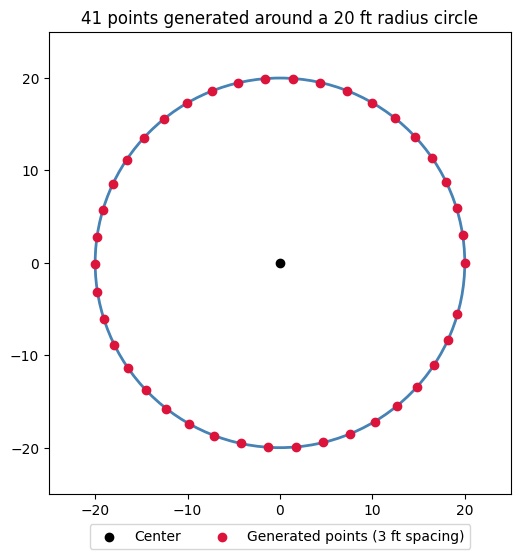

In [5]:
# Example: center at origin, edge point defines a 20-foot radius
center = (0, 0)
edge = (20, 0)
radius = math.hypot(edge[0] - center[0], edge[1] - center[1])
circle_pts = generate_points_on_circle(center, radius)

fig, ax = plt.subplots(figsize=(6, 6))
circle_outline = plt.Circle(center, radius, fill=False, color="steelblue", linewidth=2)
ax.add_patch(circle_outline)
ax.scatter(*center, color="black", zorder=5, label="Center")
ax.scatter([p.x for p in circle_pts], [p.y for p in circle_pts], color="crimson", zorder=5, label="Generated points (3 ft spacing)")
ax.set_aspect("equal")
ax.set_xlim(-radius - 5, radius + 5)
ax.set_ylim(-radius - 5, radius + 5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
ax.set_title(f"{len(circle_pts)} points generated around a {radius:.0f} ft radius circle")
plt.show()

## Notes

- The production tool reads point pairs from an ArcGIS feature class by `OBJECTID` and writes real line/point feature classes back out — this notebook swaps that I/O layer for plain `(x, y)` tuples and `matplotlib` so the underlying math is visible and testable without a license.
- Units here are treated as feet directly for clarity; the production tool works in meters internally (`spacing = 0.9144`, `min_distance_threshold = 0.6096`) since that's what the source spatial reference uses.